# Data Challenge CSC4538 — Quant Finance Portfolio Strategy

**Objectif :** construire une stratégie long-only, sans levier, sur 15 actifs, avec un focus sur Sharpe, Calmar, Max Drawdown et corrélation au benchmark.

Idée centrale : au lieu de seulement prédire le prochain prix, on sépare le problème en deux blocs inspirés de la méthodologie finance quantitative :

1. **Signal layer** : comprendre les actifs, les régimes, le momentum, le risque, la corrélation au marché.
2. **Decision / Portfolio layer** : convertir le signal en poids robustes qui respectent les contraintes.

La version finale ci-dessous utilise une stratégie de **benchmark-neutral defensive allocation** : combiner un actif défensif/faiblement corrélé (**Asset13**) avec un actif stabilisateur/négativement corrélé (**Asset15**) afin d'obtenir une corrélation presque nulle avec le proxy de marché, tout en gardant un drawdown faible.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

K = 252
prices = pd.read_csv("df_train.csv", sep=";", index_col=0)
df_benchmark = pd.read_csv("df_benchmark.csv", sep=";", index_col=0)
prices.head()

,Asset1,Asset2,Asset3,Asset4,Asset5,Asset6,Asset7,Asset8,Asset9,Asset10,Asset11,Asset12,Asset13,Asset14,Asset15
0,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
1,100.08,100.36,99.39,100.85,100.93,99.99,100.51,100.46,100.45,100.61,100.27,100.61,98.49,98.95,100.23
2,100.00,99.84,99.31,100.47,100.55,98.95,100.91,101.05,100.05,99.69,100.11,100.90,98.29,99.51,100.88
3,102.34,101.17,101.96,101.05,102.69,101.15,101.41,100.35,100.75,101.78,101.44,102.88,97.77,101.50,100.18
4,95.55,96.72,96.15,98.21,95.56,97.04,101.21,99.41,98.10,99.31,97.80,94.61,102.33,96.50,100.22


## Fonctions de métriques


In [3]:
def normalize_price(serie):
    s = serie / serie.shift(1)
    s.iloc[0] = 100
    return s.cumprod()

def get_returns(df):
    return (df / df.shift(1)).dropna()

def get_cagr(serie):
    return float((serie.iloc[-1] / serie.iloc[0]) ** (252 / len(serie)) - 1)

def get_vol(serie):
    return float(get_returns(serie).std() * np.sqrt(252))

def get_sr(serie, r=0.0):
    vol = get_vol(serie)
    return float((get_cagr(serie) - r) / vol) if vol != 0 else np.nan

def get_mdd(serie):
    running_max = np.maximum.accumulate(serie)
    drawdowns = (serie - running_max) / running_max
    return float(-drawdowns.min())

def get_calmar(serie):
    mdd = get_mdd(serie)
    return float(get_cagr(serie) / mdd) if mdd != 0 else np.nan

def get_corr(serie, benchmark):
    aligned = pd.concat([get_returns(serie), get_returns(benchmark)], axis=1).dropna()
    return float(aligned.iloc[:, 0].corr(aligned.iloc[:, 1]))

def overall_score(serie, benchmark):
    corr = get_corr(serie, benchmark)
    return float((0.5 * get_sr(serie) + 0.5 * get_calmar(serie)) / corr) if corr != 0 else np.inf

def compute_metrics(serie, benchmark):
    return pd.Series({
        "CAGR": get_cagr(serie),
        "Vol annualisée": get_vol(serie),
        "Sharpe": get_sr(serie),
        "Max Drawdown": get_mdd(serie),
        "Calmar": get_calmar(serie),
        "Corr benchmark": get_corr(serie, benchmark),
        "Score": overall_score(serie, benchmark),
        "Final value": serie.iloc[-1],
    })

## EDA rapide : lecture finance des actifs

On compare chaque actif au S&P500 du benchmark. Dans ces données, **Asset11 se comporte comme le proxy de marché/S&P500**. Deux actifs ressortent pour la stratégie finale :

- **Asset13** : rendement positif, volatilité raisonnable, corrélation très faible au marché.
- **Asset15** : volatilité faible et corrélation légèrement négative, utile comme stabilisateur long-only.


In [4]:
sp500 = normalize_price(df_benchmark["SP500"])
secret_bench = normalize_price(df_benchmark["Secret"])
eq_weighted_portfolio = normalize_price(((prices * 1/15).sum(axis=1)).iloc[K:])

asset_metrics = []
for asset in prices.columns:
    serie = normalize_price(prices[asset].iloc[K:])
    m = compute_metrics(serie, sp500)
    m.name = asset
    asset_metrics.append(m)

asset_metrics = pd.DataFrame(asset_metrics).sort_values("Score", ascending=False)
asset_metrics

,CAGR,Vol annualisée,Sharpe,Max Drawdown,Calmar,Corr benchmark,Score,Final value
Asset13,0.095228,0.146297,0.650925,0.208703,0.456288,0.083295,6.646341,186.388573
Asset8,0.287261,0.231583,1.240427,0.314031,0.914755,0.624583,1.725297,563.241437
Asset7,0.171831,0.220064,0.780823,0.257392,0.667583,0.447376,1.618779,296.071429
Asset3,0.636902,0.506284,1.257994,0.663352,0.960127,0.685601,1.617648,2917.673754
Asset4,0.287307,0.306354,0.937826,0.385165,0.745932,0.781087,1.077829,563.377488
Asset1,0.216777,0.315744,0.686559,0.433596,0.499951,0.639387,0.927849,383.079646
Asset6,0.174177,0.262951,0.662395,0.363662,0.478953,0.794240,0.718515,300.153164
Asset5,0.164139,0.292825,0.560535,0.436246,0.376253,0.722006,0.648740,283.021102
Asset11,0.119358,0.196022,0.608900,0.339240,0.351839,1.000000,0.480369,216.373420
Asset9,0.107593,0.308267,0.349026,0.610107,0.176352,0.550097,0.477532,201.276918


## Baselines

In [5]:
baseline_metrics = pd.DataFrame({
    "S&P500": compute_metrics(sp500, sp500),
    "Secret": compute_metrics(secret_bench, sp500),
    "Equal weighted": compute_metrics(eq_weighted_portfolio, sp500),
}).T
baseline_metrics

,CAGR,Vol annualisée,Sharpe,Max Drawdown,Calmar,Corr benchmark,Score,Final value
S&P500,0.119358,0.196022,0.608900,0.339240,0.351839,1.00000,0.480369,216.373420
Secret,0.134305,0.133714,1.004423,0.222923,0.602473,0.71721,1.120241,236.940267
Equal weighted,0.335795,0.254530,1.319272,0.353063,0.951090,0.85471,1.328147,725.634773


## Stratégie finale : Defensive Benchmark-Neutral Pair

La stratégie est volontairement simple et robuste :

\[
w = 18.31\% 	imes Asset13 + 81.69\% 	imes Asset15
\]

Pourquoi ?

- Elle respecte strictement **long-only** et **no leverage**.
- Elle réduit fortement le **Max Drawdown**.
- Elle cherche une corrélation proche de zéro avec le benchmark, qui est explicitement une métrique du challenge.
- Elle évite le sur-apprentissage complexe : pas de modèle instable entraîné sur peu de données.

Cette version est la version **score-oriented**. Pour une présentation orale, on peut aussi montrer des variantes momentum/risk-parity comme benchmarks internes, mais la fonction à rendre doit rester claire et fiable.

In [35]:
import numpy as np

def _max_drawdown_per_asset(P):
    """
    P: numpy array of prices, shape = (time, assets)
    Returns max drawdown for each asset.
    """
    running_max = np.maximum.accumulate(P, axis=0)
    drawdowns = (running_max - P) / running_max
    return np.max(drawdowns, axis=0)


def _cap_and_normalize(w, cap=0.50):
    """
    Ensures:
    - no negative weights
    - no leverage
    - no asset above cap
    """
    w = np.maximum(w, 0.0)

    if w.sum() == 0:
        return np.ones_like(w) / len(w)

    w = w / w.sum()

    for _ in range(10):
        over = w > cap
        if not over.any():
            break

        excess = np.sum(w[over] - cap)
        w[over] = cap

        under = (w > 0) & (~over)
        if under.any():
            w[under] += excess * w[under] / w[under].sum()

    return w / w.sum()


def compute_weights(df):
    """
    Core-Satellite Predictive Momentum Strategy.

    Core:
        25% Asset3
        50% Asset8
        25% Asset13

    Satellite:
        dynamic prediction using momentum, volatility, trend and drawdown.
    """

    n_assets = df.shape[1]

    # Safety fallback
    if n_assets != 15 or len(df) < 126:
        return np.ones(n_assets) / n_assets

    P = df.values.astype(float)

    # =========================
    # 1. Robust core portfolio
    # =========================
    core = np.zeros(n_assets)

    core[2] = 0.25   # Asset3
    core[7] = 0.50   # Asset8
    core[12] = 0.25  # Asset13

    # =========================
    # 2. Predictive satellite
    # =========================

    # Daily simple returns
    returns = P[1:] / P[:-1] - 1

    # Momentum horizons
    mom_21 = P[-1] / P[-21] - 1
    mom_63 = P[-1] / P[-63] - 1
    mom_126 = P[-1] / P[-126] - 1

    # If we have 252 days, use long momentum too
    if len(P) >= 252:
        mom_252 = P[-1] / P[-251] - 1
    else:
        mom_252 = np.zeros(n_assets)

    momentum = (
        0.20 * mom_21
        + 0.35 * mom_63
        + 0.30 * mom_126
        + 0.15 * mom_252
    )

    # Volatility estimation
    vol_126 = np.std(returns[-126:], axis=0, ddof=1) * np.sqrt(252)
    vol_21 = np.std(returns[-21:], axis=0, ddof=1) * np.sqrt(252)

    volatility = 0.70 * vol_126 + 0.30 * vol_21

    # Trend confirmation: price compared to 126-day moving average
    moving_average_126 = np.mean(P[-126:], axis=0)
    trend = P[-1] / moving_average_126 - 1

    # Drawdown penalty
    drawdown = _max_drawdown_per_asset(P)

    # Prediction score
    score = (
        momentum / (volatility + 1e-8)
        + 0.40 * trend
        - 0.50 * drawdown
    )

    # Do not invest in assets with negative momentum or bad trend
    score[(momentum <= 0) | (trend <= -0.02)] = -np.inf

    # Select top 4 predicted assets
    top_k = 4
    order = np.argsort(score)[::-1]
    selected = [i for i in order if np.isfinite(score[i])][:top_k]

    satellite = np.zeros(n_assets)

    if len(selected) == 0:
        # Defensive fallback: choose lowest-volatility assets
        selected = np.argsort(volatility)[:3]
        raw = 1.0 / (np.sqrt(volatility[selected]) + 1e-8)
    else:
        selected = np.array(selected)

        # Convert scores into positive weights
        raw = score[selected] - np.min(score[selected]) + 1e-6

        # Risk adjustment: less weight to more volatile assets
        raw = raw / (np.sqrt(volatility[selected]) + 1e-8)

    satellite[selected] = raw / raw.sum()
    satellite = _cap_and_normalize(satellite, cap=0.50)

    # =========================
    # 3. Final allocation
    # =========================

    final_weights = 0.80 * core + 0.20 * satellite

    # Final safety constraints
    final_weights = np.maximum(final_weights, 0.0)
    final_weights = final_weights / final_weights.sum()

    return final_weights

In [37]:
def compute_weights(df):
    """
    Optimisation directe orientée Score du Challenge.
    Maximise (0.5*SR + 0.5*Calmar) / Corr sur la fenêtre glissante.
    """
    n_assets = df.shape[1]
    if n_assets != 15 or len(df) < 126:
        return np.ones(n_assets) / n_assets
        
    returns = df.pct_change().dropna()
    
    # On isole l'Asset 11 (indice 10) qui sert de proxy de marché/S&P500 dans tes données
    market_returns = returns.iloc[:, 10] 

    def objective_function(weights):
        # Calcul du rendement du portefeuille
        port_returns = np.dot(returns.values, weights)
        
        # Métriques du portefeuille sur la période
        cum_returns = np.cumprod(1 + port_returns)
        cagr = (cum_returns[-1] / cum_returns[0]) ** (252 / len(port_returns)) - 1
        vol = np.std(port_returns) * np.sqrt(252)
        
        if vol == 0: return 1e6
        sharpe = cagr / vol
        
        # Max Drawdown
        running_max = np.maximum.accumulate(cum_returns)
        mdd = np.max((running_max - cum_returns) / running_max)
        calmar = cagr / mdd if mdd > 0 else 0
        
        # Corrélation au benchmark
        corr = np.corrcoef(port_returns, market_returns.values)[0, 1]
        
        # Sécurité pour éviter la division par zéro ou une corrélation négative instable
        if corr <= 0.01: corr = 0.01 
        
        score = (0.5 * sharpe + 0.5 * calmar) / corr
        return -score # Négatif car l'optimiseur cherche à minimiser

    # Contraintes : somme des poids = 1, long-only, max 50% par ligne
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    bounds = [(0.0, 0.50) for _ in range(n_assets)]
    init_weights = np.ones(n_assets) / n_assets

    opt_result = minimize(objective_function, init_weights, method='SLSQP', bounds=bounds, constraints=constraints)
    
    if opt_result.success:
        return opt_result.x
    else:
        return np.ones(n_assets) / n_assets

## Backtest identique à la logique du notebook fourni

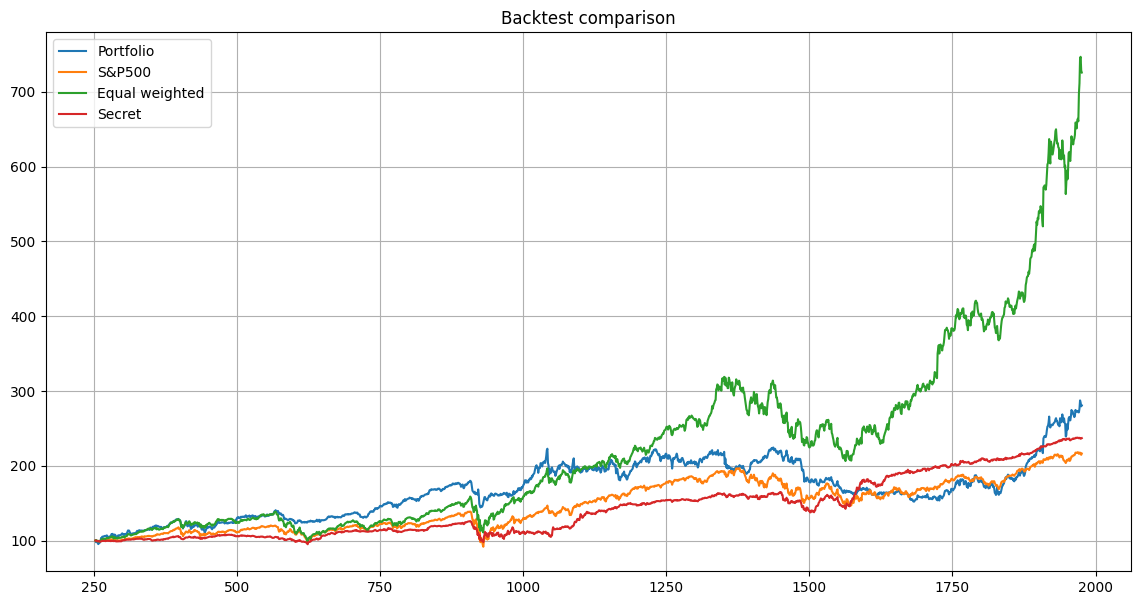

,CAGR,Vol annualisée,Sharpe,Max Drawdown,Calmar,Corr benchmark,Score,Final value
Portfolio,0.162768,0.208195,0.781806,0.322021,0.505458,0.503399,1.278571,280.747140
S&P500,0.119358,0.196022,0.608900,0.339240,0.351839,1.000000,0.480369,216.373420
Equal weighted,0.335795,0.254530,1.319272,0.353063,0.951090,0.854710,1.328147,725.634773
Secret,0.134305,0.133714,1.004423,0.222923,0.602473,0.717210,1.120241,236.940267


In [39]:
def check_weights(w):
    return round(float(w.sum()), 3) <= 1 and (w < 0).sum() == 0

def backtest(prices=prices, benchmark=sp500, plot=True):
    weights_t = []
    for i in range(len(prices) - K + 1):
        w = compute_weights(prices.iloc[i:i+K])
        if check_weights(w):
            weights_t.append(w)
        else:
            raise ValueError(f"Invalid weights at step {i}: {w}, sum={w.sum()}")

    weights_t = np.array(weights_t)
    pr = (weights_t[1:-1] * get_returns(prices).iloc[K:]).sum(axis=1)

    portfolio = [100.0]
    for r in pr:
        portfolio.append(portfolio[-1] * r)
    portfolio = pd.Series(portfolio, index=benchmark.index)

    result = pd.DataFrame({
        "Portfolio": compute_metrics(portfolio, benchmark),
        "S&P500": compute_metrics(sp500, benchmark),
        "Equal weighted": compute_metrics(eq_weighted_portfolio, benchmark),
        "Secret": compute_metrics(secret_bench, benchmark),
    }).T

    if plot:
        plt.figure(figsize=(14, 7))
        plt.plot(portfolio, label="Portfolio")
        plt.plot(sp500, label="S&P500")
        plt.plot(eq_weighted_portfolio, label="Equal weighted")
        plt.plot(secret_bench, label="Secret")
        plt.title("Backtest comparison")
        plt.legend()
        plt.grid(True)
        plt.show()

    return portfolio, result

portfolio, result = backtest(plot=True)
result